# Проект: классификация

In [680]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
import plotly.express as px

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [681]:
df = pd.read_csv(r'C:\Users\vladk\IDLE\Data\bank_fin.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [682]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

In [683]:
df['balance']=df['balance'].replace({' \$': ''}, regex=True)

In [684]:
df['balance']=df['balance'].str.replace(' ', '').str.replace(',', '.').astype(float)

In [685]:
df['balance']

0        2343.0
1          45.0
2        1270.0
3        2476.0
4         184.0
          ...  
11157       1.0
11158     733.0
11159      29.0
11160       0.0
11161       0.0
Name: balance, Length: 11162, dtype: float64

### Задание 2

In [686]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [687]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'].mean()

1529.1290293615875

### Задание 4

In [688]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
df['balance'].fillna(df['balance'].median(), inplace=True)

In [689]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [690]:
df['balance'].mean()

1526.9360329690019

### Задание 5

In [691]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
df['job']=df['job'].replace('unknown', df['job'].mode()[0])

In [692]:
df['education']=df['education'].replace('unknown', df['education'].mode()[0])

In [693]:
df[(df['education']==df['education'].mode()[0])&(df['job']==df['job'].mode()[0])]['balance'].mean()

1598.8829787234042

### Задание 6

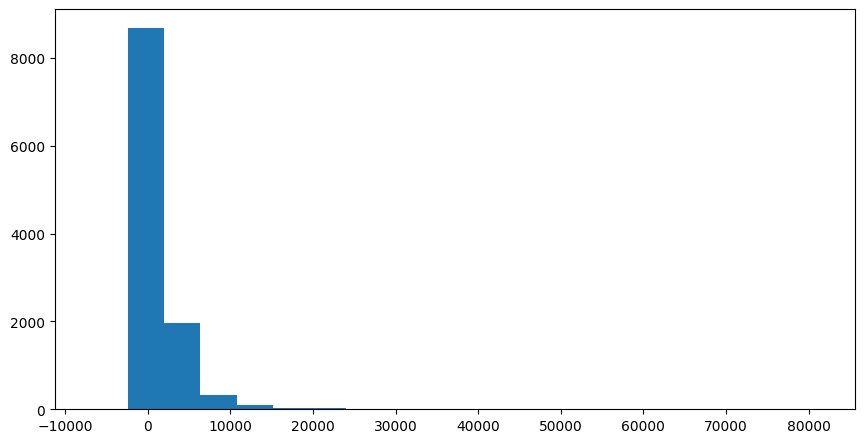

In [694]:
# удалите все выбросы для признака balance
# ваш код
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.hist(
    df['balance'],
    bins=20
)
axes.locator_params (axis='x', nbins= 15)

In [695]:
Q1 = np.percentile(df['balance'], 25)
Q3 = np.percentile(df['balance'], 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound = round(lower_bound)
upper_bound = round(upper_bound)

print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")

Нижняя граница: -2241
Верхняя граница: 4063


In [696]:
df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

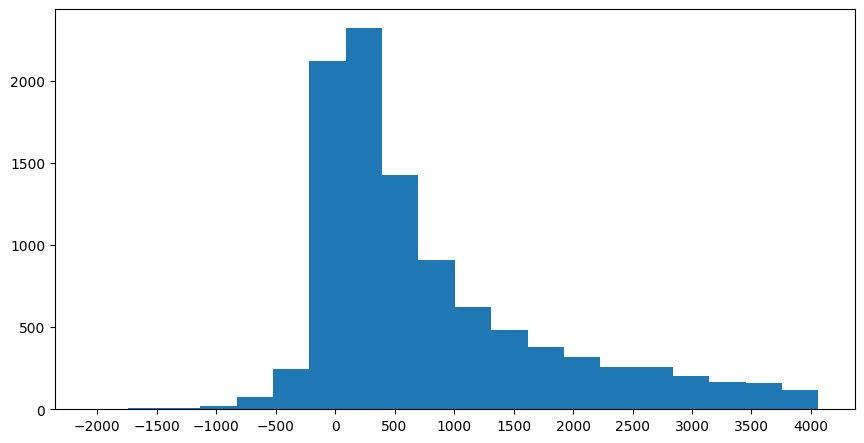

In [697]:
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.hist(
    df['balance'],
    bins=20
)
axes.locator_params (axis='x', nbins= 15)

In [698]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        10105 non-null  int64  
 1   job        10105 non-null  object 
 2   marital    10105 non-null  object 
 3   education  10105 non-null  object 
 4   default    10105 non-null  object 
 5   balance    10105 non-null  float64
 6   housing    10105 non-null  object 
 7   loan       10105 non-null  object 
 8   contact    10105 non-null  object 
 9   day        10105 non-null  int64  
 10  month      10105 non-null  object 
 11  duration   10105 non-null  int64  
 12  campaign   10105 non-null  int64  
 13  pdays      10105 non-null  int64  
 14  previous   10105 non-null  int64  
 15  poutcome   10105 non-null  object 
 16  deposit    10105 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 1.4+ MB


## Часть 2:  Разведывательный анализ

### Задание 1

In [699]:
deposit_counts = df['deposit'].value_counts().reset_index()
deposit_counts.columns = ['deposit', 'count']

fig = px.bar(
    deposit_counts,
    x='deposit', 
    y='count', 
    title='Распределение депозитов', 
    labels={'deposit': 'Deposit', 'count': 'Count'})
fig.show()

### Задания 2 и 3

In [700]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

In [701]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
df.describe(include = 'object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


### Задание 6

In [702]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код
df['poutcome'].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

### Задание 7

<Axes: xlabel='month'>

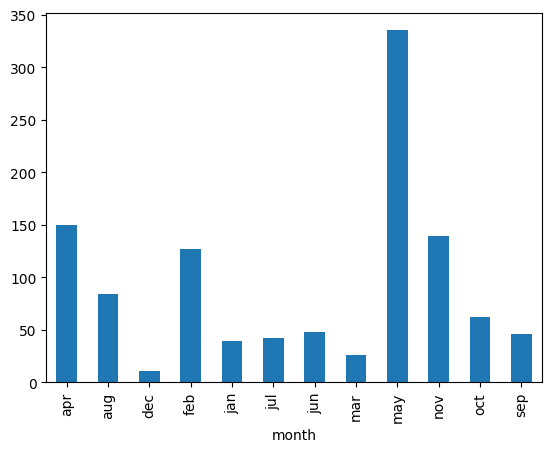

In [703]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
# Используем группировку 'deposit' по индексу 'poutcome'

types = df.groupby(df['poutcome']=='failure')['month'].value_counts(normalize=False).unstack()
types = types.loc[True]
types.plot(kind='bar')

### Задание 8

In [704]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
def age_group(age):
    if age < 30:
        return '<30'
    elif age < 41:
        return '30-40'
    elif age < 51:
        return '40-50'
    elif age < 61:
        return '50-60'
    else:
        return '60+'

# Применение функции к столбцу с возрастом
df['age_group'] = df['age'].map(age_group)

In [705]:
grouped_by_active = df.pivot_table(index='age_group', columns='deposit', aggfunc='size', fill_value=0).reset_index()

# Построение графика
fig = px.bar(
    data_frame=grouped_by_active,
    x='age_group',
    y=['yes', 'no'],
    title='чё по депозиту у молодых и старых чувачков',
    text_auto=True,
    barmode='group'
)
fig.show()

### Задания 9 и 10

In [706]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
grouped_by_active = df.pivot_table(index='marital', columns='deposit', aggfunc='size', fill_value=0).reset_index()

# Построение графика
fig = px.bar(
    data_frame=grouped_by_active,
    x='marital',
    y=['yes', 'no'],
    title='чё по депозиту у обречённых',
    text_auto=True,
    barmode='group'
)
fig.show()

In [707]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
grouped_by_active = df.pivot_table(index='education', columns='deposit', aggfunc='size', fill_value=0).reset_index()

# Построение графика
fig = px.bar(
    data_frame=grouped_by_active,
    x='education',
    y=['yes', 'no'],
    title='чё по депозиту у ботаников',
    text_auto=True,
    barmode='group'
)
fig.show()

In [708]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
grouped_by_active = df.pivot_table(index='job', columns='deposit', aggfunc='size', fill_value=0).reset_index()

# Построение графика
fig = px.bar(
    data_frame=grouped_by_active,
    x='job',
    y=['yes', 'no'],
    title='чё по депозиту у рабочего класса',
    text_auto=True,
    barmode='group'
)
fig.show()

### Задание 11

Text(0.5, 1.0, 'Тепловая карта депозита по семейному статусу и образованию')

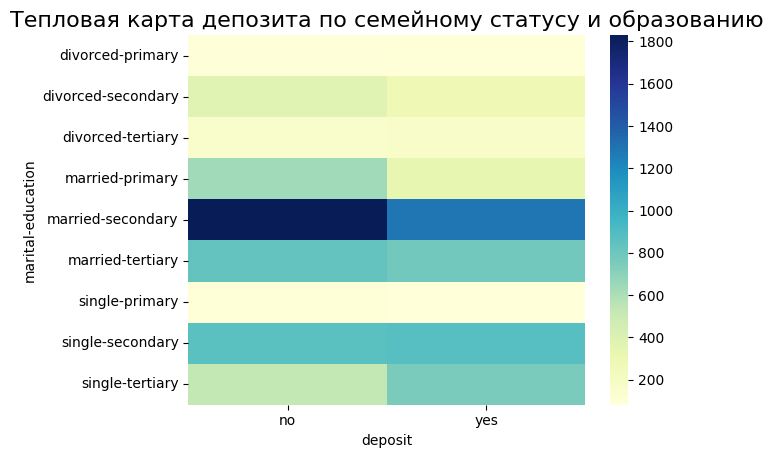

In [709]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
dt = df.groupby(['marital', 'education'])['deposit'].value_counts(normalize=False).unstack()

heatmap = sns.heatmap(data=dt, cmap='YlGnBu')
heatmap.set_title('Тепловая карта депозита по семейному статусу и образованию', fontsize=16)

## Часть 3: преобразование данных

### Задание 1

In [710]:
# преобразуйте уровни образования
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])

In [711]:
df['education'].sum()

11995

In [712]:
le = LabelEncoder()
df['age_group'] = le.fit_transform(df['age_group'])

### Задания 2 и 3

In [713]:
# преобразуйте бинарные переменные в представление из нулей и единиц
from sklearn.preprocessing  import LabelBinarizer
lb = LabelBinarizer()

# Преобразование категориальных данных в бинарные представления
df['deposit'] = lb.fit_transform(df['deposit'])

In [714]:
df['deposit'].std()

0.4986712532452124

In [715]:
df['default'] = lb.fit_transform(df['default'])

In [716]:
df['housing'] = lb.fit_transform(df['housing'])

In [717]:
df['loan'] = lb.fit_transform(df['loan'])

In [718]:
df['default'].mean()+df['housing'].mean()+df['loan'].mean()

0.6354280059376547

### Задание 4

In [719]:
df = pd.get_dummies(df, columns=['job','marital','contact','month','poutcome'])
df.astype(int)

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,1,0,2343,1,0,5,1042,1,-1,...,0,0,1,0,0,0,0,0,0,1
1,56,1,0,45,0,0,5,1467,1,-1,...,0,0,1,0,0,0,0,0,0,1
2,41,1,0,1270,1,0,5,1389,1,-1,...,0,0,1,0,0,0,0,0,0,1
3,55,1,0,2476,1,0,5,579,1,-1,...,0,0,1,0,0,0,0,0,0,1
4,54,2,0,184,0,0,5,673,2,-1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,0,0,1,1,0,20,257,1,-1,...,0,0,0,0,0,0,0,0,0,1
11158,39,1,0,733,0,0,16,83,4,-1,...,1,0,0,0,0,0,0,0,0,1
11159,32,1,0,29,0,0,19,156,2,-1,...,0,0,0,0,0,0,0,0,0,1
11160,43,1,0,0,0,1,8,9,2,172,...,0,0,1,0,0,0,1,0,0,0


### Задания 5 и 6

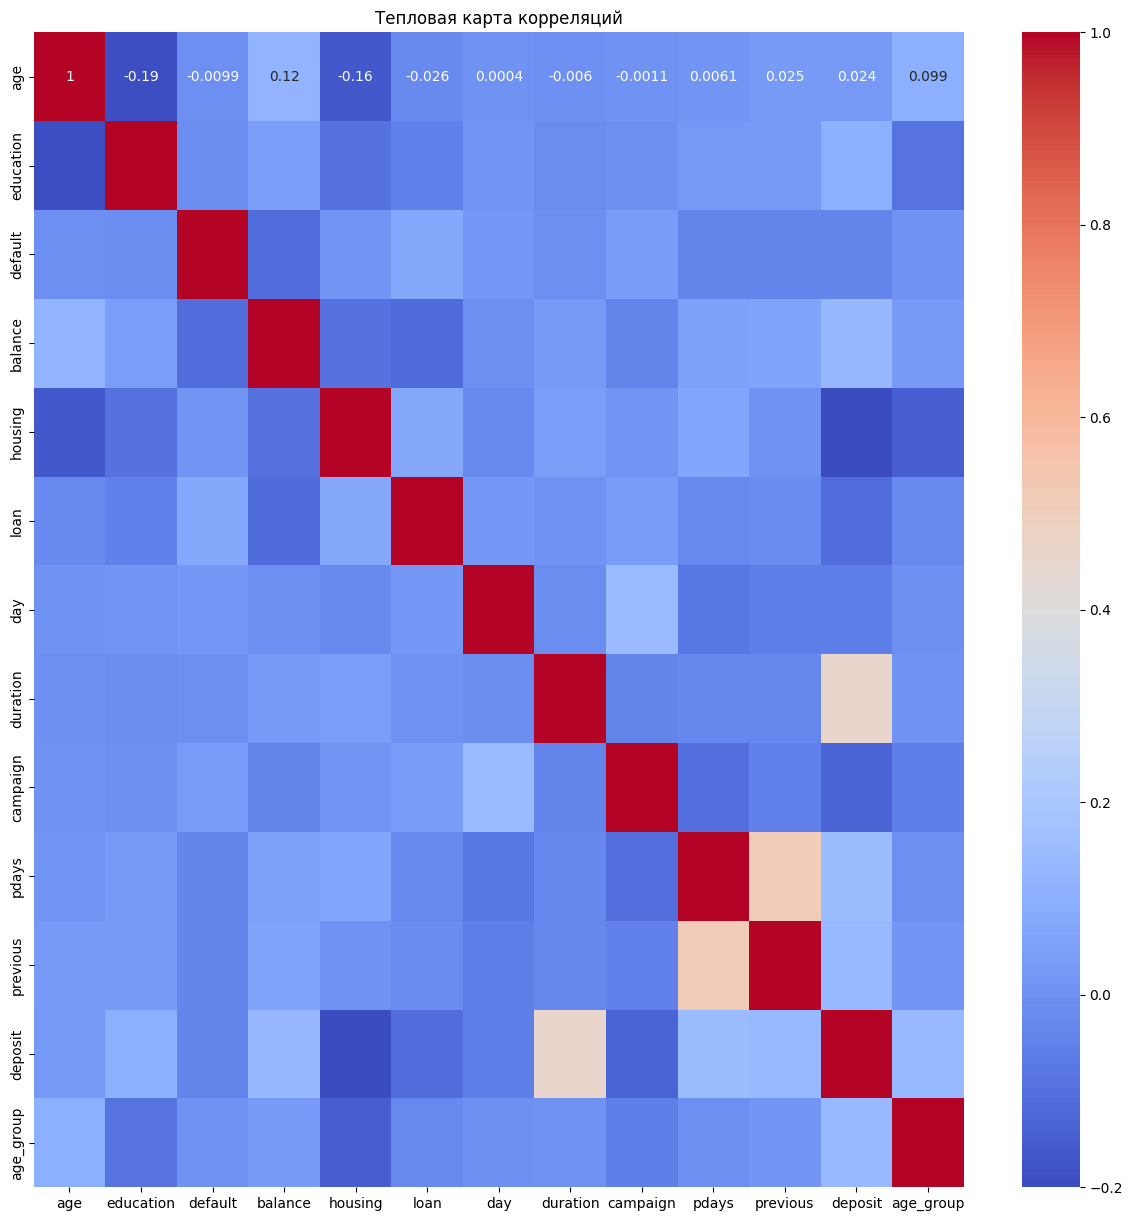

In [720]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Тепловая карта корреляций')
plt.show()

### Задания 7 и 8

In [721]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [722]:
print("Размер тестовой выборки:", len(X_test))

Размер тестовой выборки: 3335


In [723]:
# рассчитайте необходимые показатели
y_test.mean()

0.46326836581709147

### Задание 9

In [724]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector = SelectKBest(f_classif, k=15)

selector.fit(X_train, y_train)

selector.get_feature_names_out()

array(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_group', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

In [725]:
df = df[['balance', 'housing', 'duration', 'campaign', 'pdays', 
         'previous', 'age_group', 'contact_cellular', 'contact_unknown',
         'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown', 'deposit']]

X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

### Задание 10

In [726]:
# нормализуйте данные с помощью minmaxsxaler
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled[:, 0].mean().round(2)

0.47

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [737]:
# обучите логистическую регрессию и рассчитайте метрики качества
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(solver='sag', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
print('Accuracy: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Accuracy: 0.81


### Задания 2,3,4

In [755]:
# обучите решающие деревья, настройте максимальную глубину
dt = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=7
)
#Обучаем дерево по алгоритму CART
dt.fit(X_train, y_train)
#Выводим значения метрики 
y_train_pred = dt.predict(X_train)
print('Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
y_test_pred = dt.predict(X_test)
print('Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

Train: 0.83
Test: 0.81


### Задание 5

In [763]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV
param_grid = {'min_samples_split': [2, 5, 7, 10],'max_depth':[3,5,7]}
grid_search =  GridSearchCV(
        tree.DecisionTreeClassifier(
            criterion='entropy', 
            random_state=42
        ), 
    param_grid=param_grid,
    cv=3, scoring=('f1'),
    return_train_score=True
)  
%time grid_search.fit(X_train_scaled, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_test_scaled, y_test)))
y_test_pred = grid_search.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: total: 625 ms
Wall time: 770 ms
accuracy на тестовом наборе: 0.81
f1_score на тестовом наборе: 0.81
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 5}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [769]:
# обучите на ваших данных случайный лес
from sklearn.metrics import recall_score
rf = ensemble.RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    criterion='gini',
    min_samples_leaf=5,
    random_state=42
)
#Обучаем модель
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("accuracy:", accuracy)
print("recall:", recall)

accuracy: 0.8260869565217391
recall: 0.8317152103559871


### Задания 2 и 3

In [770]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import GradientBoostingRegressor

# Создаем объект класса градиентный бустинг
gb = GradientBoostingRegressor(
    learning_rate = 0.05,
    n_estimators = 300,
    min_samples_leaf = 5,
    max_depth=5, #максимальная глубина дерева
    random_state=42 #датчик генератора случайных чисел
)

# Обучаем модель
gb.fit(X_train_scaled, y_train)

# Формируем предсказание для тестовой выборки
gb_pred  = gb.predict(X_test)

In [772]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
f1

0.8158730158730159

### Задание 4

In [796]:
# объедините уже известные вам алгоритмы с помощью стекинга 
estimators = [
    ('dt', tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=7, min_samples_leaf=5)),
    ('gb',  GradientBoostingRegressor(learning_rate = 0.05, n_estimators = 300, min_samples_leaf = 5, max_depth=5, random_state=42)),
    ('lr',  LogisticRegression(solver='sag', random_state=42, max_iter=1000))
]

In [797]:
from sklearn.ensemble import StackingClassifier
reg = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression(random_state=42)
)
# Обучаем модель
reg.fit(X_train_scaled, y_train)

StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=7,
                                                       min_samples_leaf=5,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingRegressor(learning_rate=0.05,
                                                          max_depth=5,
                                                          min_samples_leaf=5,
                                                          n_estimators=300,
                                                          random_state=42)),
                               ('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42,
                                                   solver='sag'))],
                   final_estimator=LogisticRegression(random_state=42))

In [798]:
y_pred_stack = reg.predict(X_test_scaled)
print(f'Качество предсказания по precision для стекинга {round(metrics.precision_score(y_test, y_pred_stack), 2)}')

Качество предсказания по precision для стекинга 0.81


### Задание 5

In [ ]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

### Задания 6,7,8

In [814]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)
  # создаем модель
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train_scaled))

  return score

# cоздаем объект исследования
opt_rf = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")

# ищем лучшую комбинацию гиперпараметров n_trials раз
opt_rf.optimize(optuna_rf, n_trials=50)

# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(opt_rf.best_params))

# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(**opt_rf.best_params, random_state=42)
model.fit(X_train_scaled, y_train)

# делаем предсказание и рассчитываем метрику
y_test_pred_rf_opt = model.predict(X_test_scaled)
print('f1_score на тестовом наборе для модели случайного леса: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_rf_opt)))
print('accuracy на тестовом наборе для модели случайного леса: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred_rf_opt)))

[I 2024-07-16 17:24:51,435] A new study created in memory with name: RandomForestClassifier
[I 2024-07-16 17:24:52,870] Trial 0 finished with value: 0.9222553792995131 and parameters: {'n_estimators': 143, 'max_depth': 30, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9222553792995131.
[I 2024-07-16 17:24:53,792] Trial 1 finished with value: 0.8767295597484277 and parameters: {'n_estimators': 115, 'max_depth': 12, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9222553792995131.
[I 2024-07-16 17:24:54,684] Trial 2 finished with value: 0.8674812030075187 and parameters: {'n_estimators': 116, 'max_depth': 28, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9222553792995131.
[I 2024-07-16 17:24:55,483] Trial 3 finished with value: 0.8668023164814526 and parameters: {'n_estimators': 106, 'max_depth': 17, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9222553792995131.
[I 2024-07-16 17:24:57,032] Trial 4 finished with value: 0.8950742767787334 and parameters: {'n_

Наилучшие значения гиперпараметров {'n_estimators': 181, 'max_depth': 28, 'min_samples_leaf': 2}
f1_score на тестовом наборе для модели случайного леса: 0.82
accuracy на тестовом наборе для модели случайного леса: 0.83
